# Penalized Cox Model
**In this notebook, we'll train and test a penalized Cox model from scikit-learn to predict 6 month survival from time of first line treatment for metastatic colorectal cancer.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc

import matplotlib.pyplot as plt

from utils.cv_predictions import cross_validated_cox_predictions

## Import

In [2]:
dtype_map = pd.read_csv('../outputs/1L_features_training_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
train_df = pd.read_csv('../outputs/1L_features_training.csv', dtype = dtype_map)
train_df.shape

(29907, 162)

In [3]:
dtype_map = pd.read_csv('../outputs/1L_features_testing_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
test_df = pd.read_csv('../outputs/1L_features_testing.csv', dtype = dtype_map)
test_df.shape

(7474, 162)

In [4]:
censored_before_6m = (len(train_df.query('event == 0 and duration < 180', engine = 'python'))/len(train_df))*100
censored_before_12m = (len(train_df.query('event == 0 and duration < 365', engine = 'python'))/len(train_df))*100

print(f'Percentage censored before 6 months: {round(censored_before_6m, 1)}%')
print(f'Percentage censored before 12 months: {round(censored_before_12m, 1)}%')

Percentage censored before 6 months: 6.8%
Percentage censored before 12 months: 11.9%


## Preprocess

### Selecting features

#### Categorical variables

In [5]:
list(train_df.select_dtypes(include = ['category']).columns)

['CrcSite',
 'met_diagnosis_year',
 'Ethnicity_mod',
 'Race_mod',
 'region',
 'BRAF_status',
 'KRAS_status',
 'NRAS_status',
 'MMR/MSI_status',
 'HER2_status',
 'HER2_percent_staining']

In [6]:
# Percent unknown
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns:
    value_props = train_df[var].value_counts(normalize=True)
    # Combine 'unknown' and 'Unknown' if both exist
    unknown_pct = value_props.get('unknown', 0) + value_props.get('Unknown', 0) + value_props.get('Unknown/Not documented', 0)
    var_dict[var] = round(unknown_pct*100, 3)

var_dict

{'CrcSite': 0,
 'met_diagnosis_year': 0,
 'Ethnicity_mod': 0,
 'Race_mod': 0,
 'region': np.float64(24.205),
 'BRAF_status': np.float64(49.096),
 'KRAS_status': np.float64(36.717),
 'NRAS_status': np.float64(51.821),
 'MMR/MSI_status': np.float64(34.738),
 'HER2_status': np.float64(70.418),
 'HER2_percent_staining': np.float64(99.886)}

In [7]:
# Percent positive
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns.drop(['CrcSite', 'met_diagnosis_year', 'Ethnicity_mod', 'Race_mod', 'region', 'HER2_percent_staining']):
    value_props = train_df[var].value_counts(normalize=True)
    pos_pct = value_props.get('positive', 0) + value_props.get('Positive', 0) 
    var_dict[var] = round(pos_pct*100, 3)

var_dict

{'BRAF_status': np.float64(5.557),
 'KRAS_status': np.float64(29.963),
 'NRAS_status': np.float64(2.103),
 'MMR/MSI_status': np.float64(4.601),
 'HER2_status': np.float64(1.979)}

In [8]:
categorical_var = [
    'CrcSite', 
    'BRAF_status',
    'KRAS_status',
    'NRAS_status',
    'MMR/MSI_status', 
    'HER2_status'
]

#### Binary variables 

In [9]:
list(train_df.select_dtypes(include = ['int']).columns)

['days_met_to_treatment',
 'GroupStage_mod_na',
 'age',
 'sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'fevers',
 'hypoxemia',
 'anticoagulant',
 'opioid',
 'steroid',
 'antibiotic',
 'diabetic_med',
 'antidepressant',
 'bone_therapy_agent',
 'immunosuppressant',
 'chf',
 'cardiac_arrhythmias',
 'valvular_disease',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'htn_complicated',
 'paralysis',
 'other_neuro',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'pud',
 'aids_hiv',
 'lymphoma',
 'rheumatic',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'alcohol_abuse',
 'drug_abuse',
 'psychoses',
 'depression',
 'van_walraven_score',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met',
 'adrenal_met',
 'peritoneum_met',
 'gi_met',
 'other_met',
 'event']

In [10]:
# Did not include days_met_to_treatment, age, van_walraven, or event; LDH not included since 80% missing
bin_list = [
    'GroupStage_mod_na',
    'sex_male',
    'ecog_newly_gte2',
    'ecog_index_na',
    'hypotension',
    'tachycardia',
    'fevers',
    'hypoxemia',
    'anticoagulant',
    'opioid',
    'steroid',
    'antibiotic',
    'diabetic_med',
    'antidepressant',
    'bone_therapy_agent',
    'immunosuppressant',
    'chf',
    'cardiac_arrhythmias',
    'valvular_disease',
    'pulm_circulation',
    'pvd',
    'htn_uncomplicated',
    'htn_complicated',
    'paralysis',
    'other_neuro',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'diabetes_complicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'pud',
    'aids_hiv',
    'lymphoma',
    'rheumatic',
    'coagulopathy',
    'obesity',
    'weight_loss',
    'fluid',
    'blood_loss_anemia',
    'deficiency_anemia',
    'alcohol_abuse',
    'drug_abuse',
    'psychoses',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'brain_met',
    'adrenal_met',
    'peritoneum_met',
    'gi_met',
    'other_met'
]

In [11]:
# Identify binary variables with >3% prevalence 
bin_var_list = []
for bin_var in bin_list:
    if (train_df[bin_var].value_counts(normalize = True)[1] >= 0.03):
        bin_var_list.append(bin_var)

In [12]:
bin_var_list

['GroupStage_mod_na',
 'sex_male',
 'ecog_index_na',
 'tachycardia',
 'opioid',
 'steroid',
 'antibiotic',
 'cardiac_arrhythmias',
 'htn_uncomplicated',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'depression',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'peritoneum_met',
 'other_met']

In [13]:
# GroupStage_mod_na and ecog_index_na added as flags later
binary_var = [
    'sex_male',
    'tachycardia',
    'opioid',
    'steroid',
    'antibiotic',
    'cardiac_arrhythmias',
    'htn_uncomplicated',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'diabetes_complicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'coagulopathy',
    'obesity',
    'weight_loss',
    'fluid',
    'blood_loss_anemia',
    'deficiency_anemia',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'peritoneum_met',
    'other_met'
]

#### Numerical variables

In [14]:
list(train_df.select_dtypes(include = ['float64']).columns)

['GroupStage_mod',
 'days_diagnosis_to_met',
 'ecog_index',
 'weight_index',
 'bmi_index',
 'percent_change_weight',
 'albumin',
 'alp',
 'alt',
 'ast',
 'bicarbonate',
 'bun',
 'calcium',
 'cea',
 'chloride',
 'creatinine',
 'hemoglobin',
 'ldh',
 'platelet',
 'potassium',
 'sodium',
 'total_bilirubin',
 'wbc',
 'albumin_max',
 'alp_max',
 'alt_max',
 'ast_max',
 'bicarbonate_max',
 'bun_max',
 'calcium_max',
 'cea_max',
 'chloride_max',
 'creatinine_max',
 'hemoglobin_max',
 'ldh_max',
 'platelet_max',
 'potassium_max',
 'sodium_max',
 'total_bilirubin_max',
 'wbc_max',
 'albumin_min',
 'alp_min',
 'alt_min',
 'ast_min',
 'bicarbonate_min',
 'bun_min',
 'calcium_min',
 'cea_min',
 'chloride_min',
 'creatinine_min',
 'hemoglobin_min',
 'ldh_min',
 'platelet_min',
 'potassium_min',
 'sodium_min',
 'total_bilirubin_min',
 'wbc_min',
 'albumin_std',
 'alp_std',
 'alt_std',
 'ast_std',
 'bicarbonate_std',
 'bun_std',
 'calcium_std',
 'cea_std',
 'chloride_std',
 'creatinine_std',
 'hemogl

In [15]:
# Added age, van_walraven_score, and days_met_to_treatment here 
numerical_var = [
    'GroupStage_mod',
    'days_diagnosis_to_met',
    'ecog_index',
    'weight_index',
    'bmi_index',
    'percent_change_weight',
    'albumin',
    'alp',
    'alt',
    'ast',
    'bicarbonate',
    'bun',
    'calcium',
    'cea',
    'chloride',
    'creatinine',
    'hemoglobin',
    'platelet',
    'potassium',
    'sodium',
    'total_bilirubin',
    'wbc',
    'alp_max',
    'alt_max',
    'ast_max',
    'calcium_max',
    'cea_max',
    'creatinine_max',
    'platelet_max',
    'potassium_max',
    'sodium_max',
    'total_bilirubin_max',
    'wbc_max',
    'albumin_min',
    'bicarbonate_min',
    'calcium_min',
    'hemoglobin_min',
    'platelet_min',
    'potassium_min',
    'sodium_min',
    'age',
    'van_walraven_score',
    'days_met_to_treatment'
]

In [16]:
all_var = categorical_var + binary_var + numerical_var

In [17]:
missing = train_df[all_var].isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score       12468
cea                       9350
cea_max                   8652
chloride                  6727
albumin                   6115
albumin_min               5779
total_bilirubin           5697
bicarbonate               5670
calcium                   5646
alt                       5588
ast                       5498
alp                       5486
potassium                 5434
sodium                    5378
total_bilirubin_max       5365
bicarbonate_min           5342
calcium_max               5317
calcium_min               5317
alt_max                   5238
bun                       5214
ast_max                   5154
alp_max                   5137
potassium_max             5102
potassium_min             5102
creatinine                5083
sodium_max                5049
sodium_min                5049
creatinine_max            4760
percent_change_weight     3602
platelet                  3462
wbc                       3454
hemoglobin                3443
platelet

In [18]:
all_var = categorical_var + binary_var + numerical_var

In [19]:
len(all_var)

75

### Setting up Y

In [20]:
y_dtype = [('event', bool), ('duration', float)]

In [21]:
# Death status and time until event needs to be stored as a structured array to be compatible with scikit-survival
train_y = np.array([tuple(x) for x in train_df[['event', 'duration']].values], 
                   dtype = y_dtype)

test_y = np.array([tuple(x) for x in test_df[['event', 'duration']].values], 
                  dtype = y_dtype)

### Creating pipeline

In [22]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_var),
        ("cat", categorical_pipeline, categorical_var),
        ("pass", "passthrough", binary_var),
    ],
    remainder="drop"
)

## Train model

In [23]:
def six_month_auc_scorer_approximate(estimator, X, y):
    """
    Approximate 180d AUC using test set for censoring estimation.
    Acceptable if censoring is light (<20%).
    """
    chf_funcs = estimator.predict_cumulative_hazard_function(X)
    risk_scores = np.array([chf(180) for chf in chf_funcs])
    auc, _ = cumulative_dynamic_auc(y, y, risk_scores, 180)
    return auc[0]

auc_scorer = make_scorer(
    six_month_auc_scorer_approximate,
    greater_is_better=True,
    needs_proba=False
)

cox = CoxPHSurvivalAnalysis()

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', cox)
])

search = GridSearchCV(
    estimator=full_pipeline,
    param_grid={'model__alpha': 10. ** np.linspace(-4, 4, 25)},
    cv=3,
    scoring=six_month_auc_scorer_approximate,
    refit=False,
    n_jobs=-1,
    verbose=1
)

search.fit(train_df[all_var], train_y)
print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Users/xavierorcutt/Dropbox/io-heterogeneity/myenv/lib/python3.13/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=3.26221e-17): result may not be accurate.
  delta = solve(
/Users/xavierorcutt/Dropbox/io-heterogeneity/myenv/lib/python3.13/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=3.32795e-17): result may not be accurate.
  delta = solve(
/Users/xavierorcutt/Dropbox/io-heterogeneity/myenv/lib/python3.13/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=7.02821e-17): result may not be accurate.
  delta = solve(
/Users/xavierorcutt/Dropbox/io-heterogeneity/myenv/lib/python3.13/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=7.16985e-17): result may not be accurate.
  delta = solve(
/Users/xavierorcutt/Dropbox/io-heterogeneity/myenv/lib/python3.13/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning:

Best params: {'model__alpha': np.float64(1000.0)}


In [24]:
results_df = pd.DataFrame(search.cv_results_)
results_df.sort_values('rank_test_score', ascending = True).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
21,5.617427,0.645579,0.299499,0.022067,1000.000000,{'model__alpha': 1000.0},0.762398,0.728799,0.757654,0.749617,0.014847,1
22,5.281160,0.104661,0.307091,0.015804,2154.434690,{'model__alpha': 2154.4346900318824},0.761120,0.728424,0.758352,0.749299,0.014803,2
20,6.220686,0.569081,0.266958,0.007462,464.158883,{'model__alpha': 464.1588833612773},0.763300,0.727890,0.755837,0.749009,0.015241,3
23,4.294120,0.398129,0.236070,0.001908,4641.588834,{'model__alpha': 4641.588833612773},0.759951,0.726801,0.757734,0.748162,0.015132,4
19,5.478931,1.026088,0.270402,0.029096,215.443469,{'model__alpha': 215.44346900318823},0.763842,0.726191,0.753453,0.747828,0.015877,5
18,6.140313,0.682346,0.293563,0.048943,100.000000,{'model__alpha': 100.0},0.764207,0.724514,0.751501,0.746740,0.016551,6
24,4.615198,0.705031,0.217482,0.007366,10000.000000,{'model__alpha': 10000.0},0.758957,0.724021,0.756047,0.746342,0.015828,7
17,6.051528,0.898884,0.297614,0.019193,46.415888,{'model__alpha': 46.41588833612773},0.764647,0.723343,0.750167,0.746052,0.017112,8
16,5.534989,0.938287,0.286745,0.017796,21.544347,{'model__alpha': 21.54434690031882},0.764855,0.722690,0.749459,0.745668,0.017421,9
15,6.002889,1.340026,0.307657,0.034592,10.000000,{'model__alpha': 10.0},0.764144,0.722358,0.749096,0.745199,0.017280,10


## Test model 

### Build final model 

In [25]:
best_alpha = search.best_params_['model__alpha']
best_cox_model = CoxPHSurvivalAnalysis(alpha = best_alpha)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_cox_model)
])

full_pipeline_final.fit(train_df[all_var], train_y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['GroupStage_mod',
                                                   'days_diagnosis_to_met',
                                                   'ecog_index', 'weight_index',
                                                   'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium', 'cea', 'chloride',
                                                   'creatinine', 'hemoglobin',
                                                   'platelet...
                                                   'chronic_pulm_disease',
                                                   'diabetes_uncomplicated',
                                                   'diabetes_complicated',
                                                   'hypothyroid',
                                                   'renal_failure',
                                                   'liver_disease',
                                                   'coagulopathy', 'obesity',
                                                   'weight_loss', 'fluid',
                                                   'blood_loss_anemia',
                                                   'deficiency_anemia',
                                                   'depression', 'lymph_met',
                                                   'thoracic_met', 'liver_met',
                                                   'bone_met', 'peritoneum_met',
                                                   'other_met'])])),
                ('model', CoxPHSurvivalAnalysis(alpha=np.float64(1000.0)))])

### Evaluate performance on test and training set 

In [26]:
final_risk_scores_test = full_pipeline_final.predict(test_df[all_var])
final_auc_test = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, 180)[0][0]

print(f"Final 180-d AUC on Test Set: {final_auc_test:.3f}")

Final 180-d AUC on Test Set: 0.759


In [27]:
# Bootstrap 1000 180d AUCs for test set 
n_bootstraps = 1000
bootstrapped_scores_test = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_test), len(final_risk_scores_test))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        test_y[indices],
        final_risk_scores_test[indices],
        180
    )[0][0]
    bootstrapped_scores_test.append(auc_yr)

# Convert to array
bootstrapped_scores_test = np.array(bootstrapped_scores_test)

# Calculate 95% CI
conf_lower_test = np.percentile(bootstrapped_scores_test, 2.5)
conf_upper_test = np.percentile(bootstrapped_scores_test, 97.5)

In [28]:
final_risk_scores_train = full_pipeline_final.predict(train_df[all_var])
final_auc_train = cumulative_dynamic_auc(train_y, train_y, final_risk_scores_train, 180)[0][0]

print(f"Final 180-d AUC on Train Set: {final_auc_train:.3f}")

Final 180-d AUC on Train Set: 0.754


In [29]:
# Bootstrap 1000 180d AUCs for train set 
n_bootstraps = 1000
bootstrapped_scores_train = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_train), len(final_risk_scores_train))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        train_y[indices],
        final_risk_scores_train[indices],
        180
    )[0][0]
    bootstrapped_scores_train.append(auc_yr)

# Convert to array
bootstrapped_scores_train = np.array(bootstrapped_scores_train)

# Calculate 95% CI
conf_lower_train = np.percentile(bootstrapped_scores_train, 2.5)
conf_upper_train = np.percentile(bootstrapped_scores_train, 97.5)

In [30]:
cox_auc_180d_data = {'model': ['cox'],
                    'auc_180d_test': final_auc_test,
                    'auc_180d_test_lower': conf_lower_test,
                    'auc_180d_test_upper': conf_upper_test,
                    'auc_180d_train': final_auc_train,
                    'auc_180d_train_lower': conf_lower_train,
                    'auc_180d_train_upper': conf_upper_train}
 
cox_auc_180d_df = pd.DataFrame(cox_auc_180d_data)

In [31]:
cox_auc_180d_df

,model,auc_180d_test,auc_180d_test_lower,auc_180d_test_upper,auc_180d_train,auc_180d_train_lower,auc_180d_train_upper
0,cox,0.758947,0.743058,0.773974,0.754287,0.745665,0.761974


In [32]:
cox_auc_180d_df.to_csv('../outputs/cox_auc_180d_df.csv', index = False, header = True)

In [33]:
# Define evaluation times
times = np.arange(30, 1810, 30)

# Calculate AUCs across times
cox_auc_over5 = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, times)[0]

# Build a dictionary mapping 'time_x' -> AUC at that time
times_data = {f"time_{int(t)}": auc for t, auc in zip(times, cox_auc_over5)}

# Create DataFrame
cox_auc_over5_df = pd.DataFrame(times_data, index=['cox'])

In [34]:
cox_auc_over5_df

,time_30,time_60,time_90,time_120,time_150,time_180,time_210,time_240,time_270,time_300,...,time_1530,time_1560,time_1590,time_1620,time_1650,time_1680,time_1710,time_1740,time_1770,time_1800
cox,0.80065,0.79353,0.784764,0.768332,0.765145,0.758947,0.752288,0.750539,0.748971,0.742776,...,0.726339,0.726508,0.725072,0.725124,0.72112,0.721456,0.722335,0.716262,0.712051,0.71225


In [35]:
cox_auc_over5_df.to_csv('../outputs/cox_auc_over5_df.csv', index = True, header = True)

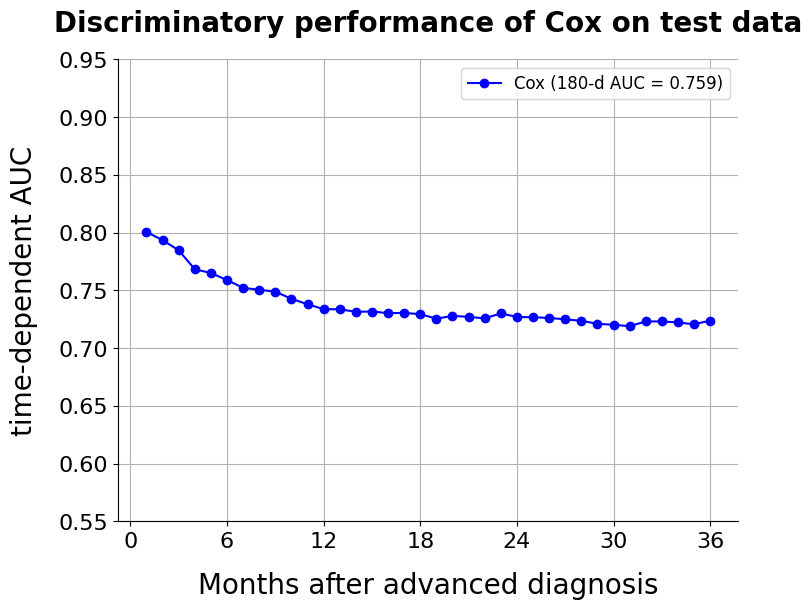

In [36]:
fig, ax0 = plt.subplots(figsize=(8, 6))

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

ax0.plot(times/30, 
         cox_auc_over5_df.loc['cox'].values[0:36], 
         'o-', 
         color = 'blue', 
         label = f"Cox (180-d AUC = {final_auc_test:.3f})")

ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.55, 1.0, 0.05))
ax0.tick_params(axis = 'both', which = 'major', labelsize = 16) 

ax0.set_title('Discriminatory performance of Cox on test data', weight = 'bold', size = 20, pad = 20)
ax0.set_xlabel('Months after advanced diagnosis', labelpad = 15, size = 20)
ax0.set_ylabel('time-dependent AUC', labelpad = 15, size = 20)
ax0.legend(loc = 'upper right', prop = {'size': 12})
ax0.grid(True)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

plt.show()

Total number of features: 75
Number of non-zero features in final model: 87


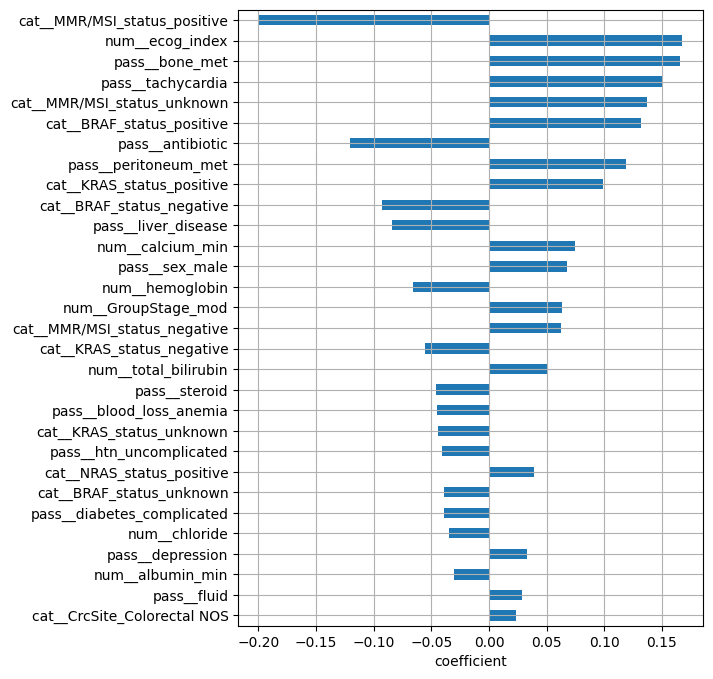

In [37]:
# Dataframe of coefficients for each variable 
cox_feature_importance = pd.DataFrame(
    full_pipeline_final.named_steps['model'].coef_,
    index = full_pipeline_final.named_steps['preprocessor'].get_feature_names_out(),
    columns = ['coefficient']
)

print('Total number of features: {}'.format(len(all_var)))

non_zero = np.sum(cox_feature_importance.iloc[:, 0] != 0)
print('Number of non-zero features in final model: {}'.format(non_zero))

non_zero_coefs = cox_feature_importance.query('coefficient != 0')
coef_order = non_zero_coefs.abs().sort_values('coefficient').tail(30).index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax = ax, legend = False)
ax.set_xlabel('coefficient')
ax.grid(True)

In [38]:
cox_feature_importance = (
    cox_feature_importance
    .reset_index()
    .rename(columns = {'index':'variable'})
)

In [39]:
cox_feature_importance.to_csv('../outputs/cox_feature_importance.csv', index = False, header = True)

## Calculating survival probabilities
**Survival probabilities are calculated for each patient using 5-fold cross-validation. For each fold, a model is trained on 80% of the data, and survival probabilities are generated for patients in the held-out 20%. This approach ensures that each patient's survival probability is based on a model that does not include them in training, providing unbiased predictions.**

### Preprocessing

In [40]:
df = pd.concat([train_df, test_df])

In [41]:
df.shape

(37381, 162)

In [42]:
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [43]:
cv_scores_df = cross_validated_cox_predictions(
    df = df,                      
    y = y,                      
    all_var = all_var,                 
    preprocessor = preprocessor,            
    survival_timepoints = (180,),     
    tau = 180,
    alpha = best_alpha,
    n_splits = 5,              
    random_state = 42,         
    verbose = True  
)

Processing fold 1/5
Processing fold 2/5
Processing fold 3/5
Processing fold 4/5
Processing fold 5/5

Number of patients in df: 37381
risk_scores computed: 37381
psurv_180 computed: 37381


In [44]:
cv_scores_df.to_csv('../outputs/cox_survival_predictions.csv')